<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Matís Godoy   
- Nombre de alumno 2: Delaney Tello

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/MDS7202-GPT-6/GPT-6)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [1]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [4]:
#Codigo Aqui
import pandas as pd
import plotly.express as px

# 1) Cargar datos
df = pd.read_csv("energia_homero.csv")
df['date'] = pd.to_datetime(df['date'])

fig = px.line(
    df, x="date", y="Energy_kWh",
    title="Consumo diario de energía de Homero (kWh)",
    labels={"date": "Fecha", "Energy_kWh": "Energía (kWh)"},
)
fig.update_layout(template="plotly_white", hovermode="x unified")
fig.show()


## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [5]:
#CODIGO AQUI
# =========================================================
# 0) Carga, split temporal y utilidades
# =========================================================
import numpy as np
import pandas as pd
from dataclasses import dataclass
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import plotly.graph_objects as go
import plotly.express as px

# --- Carga (si no lo hiciste antes) ---
df = pd.read_csv("energia_homero.csv", parse_dates=["date"])
df = (
    df.dropna(subset=["date", "Energy_kWh"])
      .drop_duplicates(subset=["date"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Prophet-like columns for convenience
df_prophet = df.rename(columns={"date":"ds", "Energy_kWh":"y"})

# --- Split temporal ---
cutoff = pd.to_datetime("2020-02-29")
mask_train = df_prophet["ds"] <= cutoff
mask_test  = df_prophet["ds"] >= pd.to_datetime("2020-03-01")

train = df_prophet.loc[mask_train].copy()
test  = df_prophet.loc[mask_test].copy()
full  = df_prophet.copy()

X_train, y_train = train[["ds"]], train["y"]
X_test,  y_test  = test[["ds"]],  test["y"]

# =========================================================
# Utilidades: transformadores de tiempo y Fourier
# =========================================================
class TimeIndex(BaseEstimator, TransformerMixin):
    """
    Transforma 'ds' (datetime) en un índice de tiempo (días desde t0 del set de entrenamiento).
    Guarda t0 en fit() para mantener consistencia train/test.
    """
    def fit(self, X, y=None):
        ds = pd.to_datetime(X["ds"])
        self.t0_ = ds.min()
        return self
    def transform(self, X):
        ds = pd.to_datetime(X["ds"])
        t = (ds - self.t0_).dt.days.to_numpy().reshape(-1, 1).astype(float)
        return t  # shape (n_samples, 1)

class FourierFeatures(BaseEstimator, TransformerMixin):
    """
    Genera términos de Fourier para una estacionalidad de periodo 'period'
    y orden 'order' (k = 1..order): sin(2πkt/P), cos(2πkt/P).
    Usa los días desde t0 (mismo origen que TimeIndex).
    """
    def __init__(self, period, order):
        self.period = period
        self.order = order

    def fit(self, X, y=None):
        ds = pd.to_datetime(X["ds"])
        self.t0_ = ds.min()
        return self

    def transform(self, X):
        ds = pd.to_datetime(X["ds"])
        t = (ds - self.t0_).dt.days.to_numpy().astype(float)
        feats = []
        for k in range(1, self.order + 1):
            angle = 2 * np.pi * k * t / self.period
            feats.append(np.sin(angle))
            feats.append(np.cos(angle))
        return np.column_stack(feats) if feats else t.reshape(-1,1)

# =========================================================
# 1) Pipeline_trend: tendencia lineal
# =========================================================
Pipeline_trend = Pipeline(steps=[
    ("time", TimeIndex()),
    ("linreg", LinearRegression())
])

# =========================================================
# 2) Entrenar tendencia, predecir y evaluar
# =========================================================
Pipeline_trend.fit(X_train, y_train)

yhat_train_trend = Pipeline_trend.predict(X_train)
yhat_test_trend  = Pipeline_trend.predict(X_test)

mae_train_trend = mean_absolute_error(y_train, yhat_train_trend)
mae_test_trend  = mean_absolute_error(y_test,  yhat_test_trend)
print(f"[Trend] MAE train: {mae_train_trend:,.3f} | MAE test: {mae_test_trend:,.3f}")

# Predicción en todo el intervalo (para graficar completo)
yhat_full_trend = Pipeline_trend.predict(full[["ds"]])

fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(x=full["ds"], y=full["y"], name="Real", mode="lines"))
fig_trend.add_trace(go.Scatter(x=full["ds"], y=yhat_full_trend, name="Predicción (Tendencia)", mode="lines"))
fig_trend.add_vrect(x0=train["ds"].min(), x1=train["ds"].max(),
                    fillcolor="LightGreen", opacity=0.2, line_width=0,
                    annotation_text="Entrenamiento", annotation_position="top left")
fig_trend.update_layout(title="Modelo de Tendencia (Lineal)", xaxis_title="Fecha", yaxis_title="kWh",
                        template="plotly_white", hovermode="x unified")
fig_trend.show()

# =========================================================
# 3) Residuos del modelo de tendencia y posible estacionalidad
# =========================================================
res_full_trend = full["y"].to_numpy() - yhat_full_trend

fig_res_trend = px.line(x=full["ds"], y=res_full_trend,
                        labels={"x":"Fecha", "y":"Error = Real - Pred"},
                        title="Residuos - Modelo de Tendencia")
fig_res_trend.update_layout(template="plotly_white", hovermode="x unified")
fig_res_trend.show()

# Chequeo rápido de autocorrelación en lags estacionales típicos
def autocorr_at_lag(series, lag):
    s = pd.Series(series)
    return s.autocorr(lag)

for lag in [7, 30, 365]:
    if len(full) > lag + 5:
        print(f"Autocorrelación de residuos (lag {lag} días): {autocorr_at_lag(res_full_trend, lag):.3f}")

# Comentario (interpretación esperada):
# Si ves oscilaciones periódicas en el gráfico de residuos y autocorrelaciones altas (p.ej., ~lag 7 y/o ~lag 365),
# hay estacionalidad semanal y/o anual que la tendencia lineal no capturó.

# =========================================================
# 4) Pipeline_seasonal: Fourier + Regresión Lineal
#    Selección de P (periodo) y n (orden) vía validación temporal interna
# =========================================================
def make_seasonal_pipeline(P, n):
    return Pipeline(steps=[
        ("fourier", FourierFeatures(period=P, order=n)),
        ("linreg", LinearRegression())
    ])

# Split de validación temporal dentro del train (último 20% como valid)
val_frac = 0.2
cut_idx = int(np.floor((1 - val_frac) * len(train)))
X_tr_sub, y_tr_sub = train.iloc[:cut_idx][["ds"]], train.iloc[:cut_idx]["y"]
X_val_sub, y_val_sub = train.iloc[cut_idx:][["ds"]], train.iloc[cut_idx:]["y"]

candidate_periods = [7, 30.5, 365.25]
candidate_orders  = [1, 2, 3, 5, 10]

best = None
for P in candidate_periods:
    for n in candidate_orders:
        pipe = make_seasonal_pipeline(P, n)
        pipe.fit(X_tr_sub, y_tr_sub)
        y_val_hat = pipe.predict(X_val_sub)
        mae_val = mean_absolute_error(y_val_sub, y_val_hat)
        if (best is None) or (mae_val < best["mae"]):
            best = {"P": P, "n": n, "mae": mae_val}

print(f"Mejor combinación en validación interna -> P={best['P']} días, n={best['n']} (MAE val={best['mae']:.3f})")

# Construimos el pipeline final con esos hiperparámetros
Pipeline_seasonal = make_seasonal_pipeline(best["P"], best["n"])

# =========================================================
# 5) Entrenar estacionalidad, predecir y evaluar (train/test y completo)
# =========================================================
Pipeline_seasonal.fit(X_train, y_train)

yhat_train_seas = Pipeline_seasonal.predict(X_train)
yhat_test_seas  = Pipeline_seasonal.predict(X_test)
mae_train_seas  = mean_absolute_error(y_train, yhat_train_seas)
mae_test_seas   = mean_absolute_error(y_test,  yhat_test_seas)
print(f"[Seasonal] MAE train: {mae_train_seas:,.3f} | MAE test: {mae_test_seas:,.3f}")

yhat_full_seas = Pipeline_seasonal.predict(full[["ds"]])

fig_seas = go.Figure()
fig_seas.add_trace(go.Scatter(x=full["ds"], y=full["y"], name="Real", mode="lines"))
fig_seas.add_trace(go.Scatter(x=full["ds"], y=yhat_full_seas, name=f"Pred (Fourier P={best['P']}, n={best['n']})", mode="lines"))
fig_seas.add_vrect(x0=train["ds"].min(), x1=train["ds"].max(),
                   fillcolor="LightGreen", opacity=0.2, line_width=0,
                   annotation_text="Entrenamiento", annotation_position="top left")
fig_seas.update_layout(title="Modelo Estacional (Fourier + Regresión Lineal)", xaxis_title="Fecha", yaxis_title="kWh",
                       template="plotly_white", hovermode="x unified")
fig_seas.show()

# =========================================================
# 6) Residuos del modelo estacional y comentario
# =========================================================
res_full_seas = full["y"].to_numpy() - yhat_full_seas

fig_res_seas = px.line(x=full["ds"], y=res_full_seas,
                       labels={"x":"Fecha", "y":"Error = Real - Pred"},
                       title=f"Residuos - Modelo Estacional (P={best['P']}, n={best['n']})")
fig_res_seas.update_layout(template="plotly_white", hovermode="x unified")
fig_res_seas.show()

for lag in [7, 30, 365]:
    if len(full) > lag + 5:
        print(f"[Seasonal] Autocorrelación residuos (lag {lag}): {autocorr_at_lag(res_full_seas, lag):.3f}")


[Trend] MAE train: 10.568 | MAE test: 8.656


Autocorrelación de residuos (lag 7 días): 0.712
Autocorrelación de residuos (lag 30 días): 0.596
Autocorrelación de residuos (lag 365 días): 0.580
Mejor combinación en validación interna -> P=365.25 días, n=2 (MAE val=4.495)
[Seasonal] MAE train: 5.434 | MAE test: 4.342


[Seasonal] Autocorrelación residuos (lag 7): 0.260
[Seasonal] Autocorrelación residuos (lag 30): 0.180
[Seasonal] Autocorrelación residuos (lag 365): -0.072


## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [6]:
!pip install prophet --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [7]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

**Respuesta:**

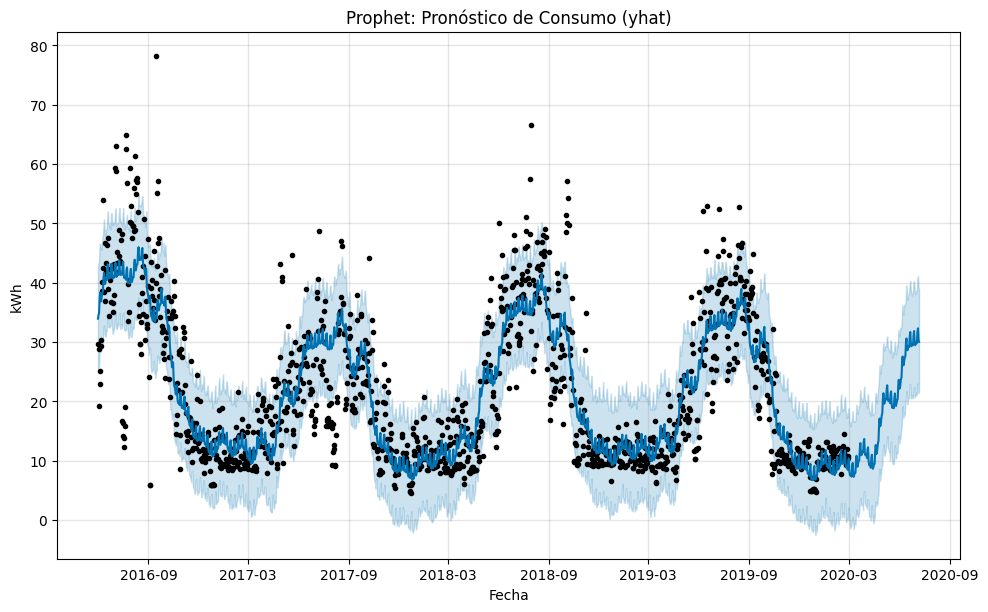

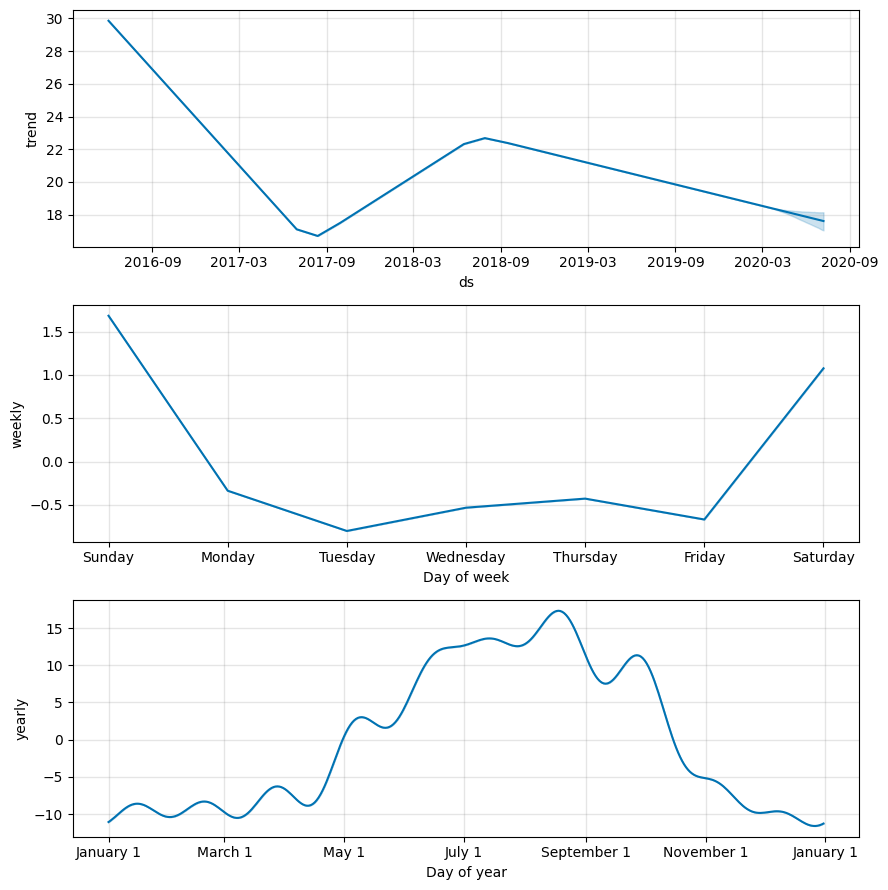

MAE (train): 4.820
MAE (test) : 4.956


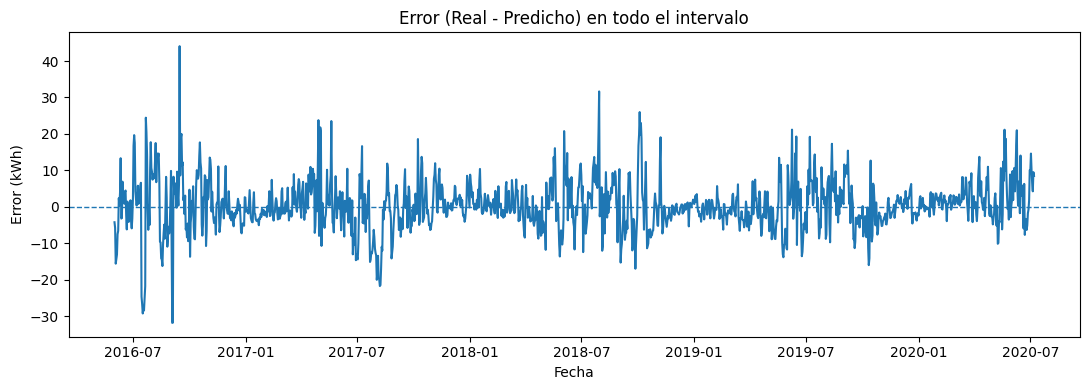

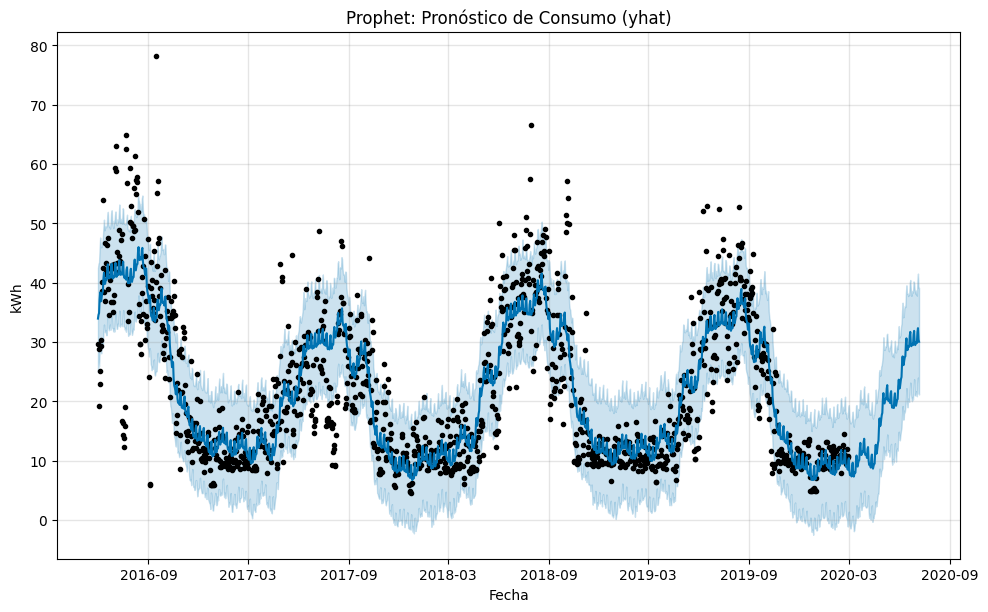

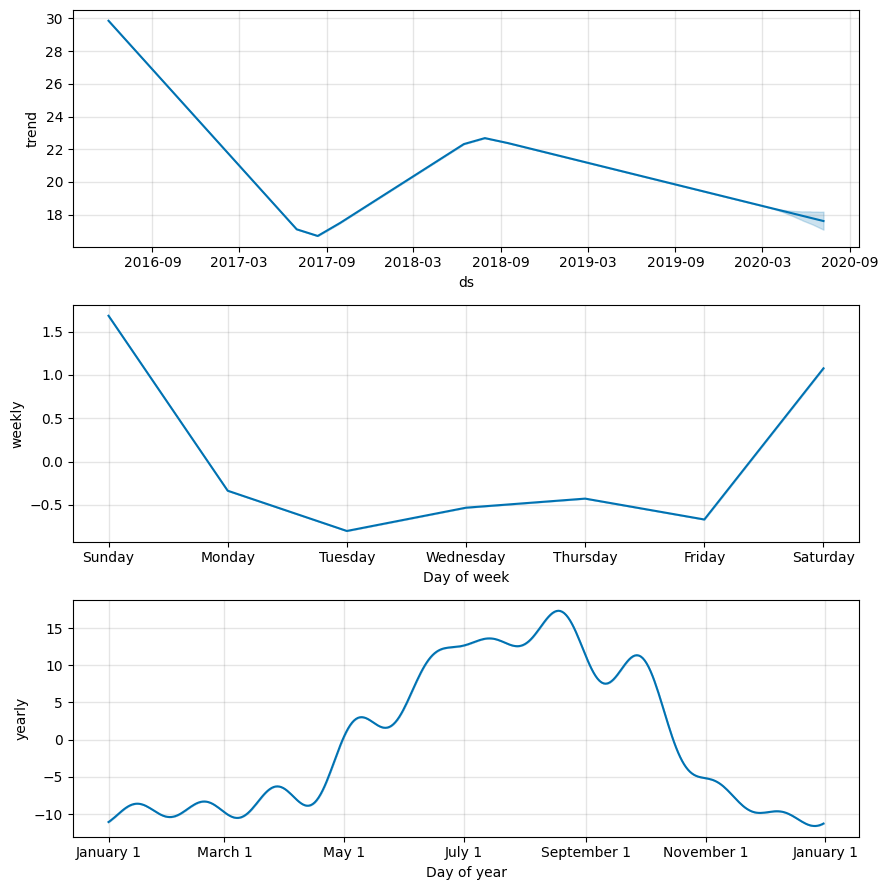

MAE (train): 4.820
MAE (test) : 4.956


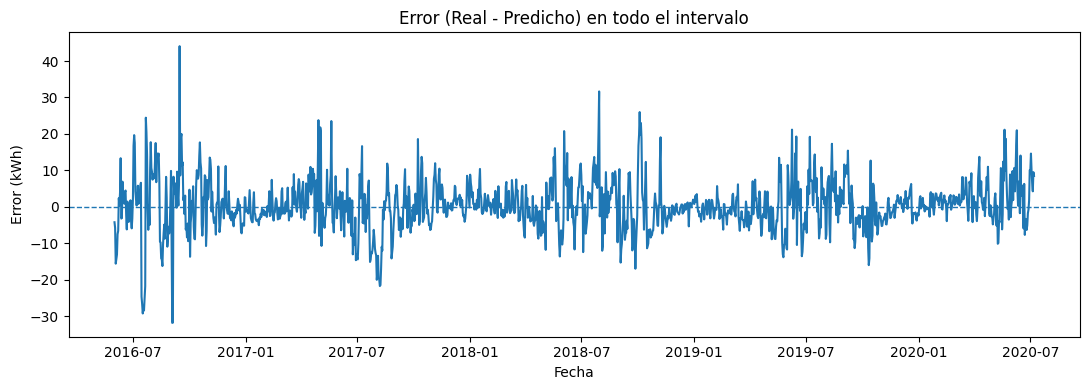

In [8]:
#CODIGO AQUI

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# (Carga si fuese necesario)
df = pd.read_csv("energia_homero.csv", parse_dates=["date"])
df = (df
      .dropna(subset=["date", "Energy_kWh"])
      .drop_duplicates(subset=["date"])
      .sort_values("date")
      .reset_index(drop=True))

# Split temporal
cutoff = pd.to_datetime("2020-02-29")
train = df[df["date"] <= cutoff].copy()
test  = df[df["date"] >= pd.to_datetime("2020-03-01")].copy()

# Renombrar a formato Prophet
train = train.rename(columns={"date": "ds", "Energy_kWh": "y"})
test  = test.rename(columns={"date": "ds", "Energy_kWh": "y"})

# =========================
# 2) Ajuste del modelo y predicciones
# =========================
# Prophet por defecto modela tendencia + estacionalidades (semanal y anual para datos diarios)
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,   # para datos diarios, suele no ser necesaria la diaria
    seasonality_mode="additive"
)
m.fit(train)  # ajuste con set de entrenamiento

# Predicciones sobre test
forecast_test = m.predict(test[["ds"]])  # contiene yhat, yhat_lower, yhat_upper

# (Opcional) Predicciones sobre train (para MAE de train)
forecast_train = m.predict(train[["ds"]])

# (Para gráficos globales: predicción en todo el intervalo train + test)
future_full = m.make_future_dataframe(periods=len(test), freq="D")
forecast_full = m.predict(future_full)

# =========================
# 3) Gráficos: predicción y componentes
# =========================
# a) Predicción (usa el objeto forecast_full)
fig1 = m.plot(forecast_full)
plt.title("Prophet: Pronóstico de Consumo (yhat)"); plt.xlabel("Fecha"); plt.ylabel("kWh")
plt.show()

# b) Componentes (tendencia y estacionalidades)
fig2 = m.plot_components(forecast_full)
plt.show()

# =========================
# 4) MAE en train y test
# =========================
mae_train = mean_absolute_error(train["y"], forecast_train["yhat"])
mae_test  = mean_absolute_error(test["y"],  forecast_test["yhat"])
print(f"MAE (train): {mae_train:,.3f}")
print(f"MAE (test) : {mae_test:,.3f}")

# =========================
# 5) Gráfico del error (Real - Predicho) en todo el intervalo
# =========================
# Unimos y calculamos residuo sobre todo el rango disponible
full_actual = pd.concat([train[["ds","y"]], test[["ds","y"]]], ignore_index=True)
full_pred   = forecast_full[["ds","yhat"]]

full_merged = full_actual.merge(full_pred, on="ds", how="left").sort_values("ds")
full_merged["error"] = full_merged["y"] - full_merged["yhat"]

# Gráfico de errores
plt.figure(figsize=(11,4))
plt.plot(full_merged["ds"], full_merged["error"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Error (Real - Predicho) en todo el intervalo")
plt.xlabel("Fecha"); plt.ylabel("Error (kWh)")
plt.tight_layout(); plt.show()

# Comentario orientativo:
# - Si la serie tiene estacionalidad, Prophet la mostrará en 'plot_components' (p. ej., semanal y/o anual).
# - Si el modelo capturó bien la estacionalidad, el gráfico de errores debería verse “ruidoso”
#   sin ondas periódicas marcadas ni autocorrelaciones fuertes en lags 7 o 365.
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# (Carga si fuese necesario)
df = pd.read_csv("energia_homero.csv", parse_dates=["date"])
df = (df
      .dropna(subset=["date", "Energy_kWh"])
      .drop_duplicates(subset=["date"])
      .sort_values("date")
      .reset_index(drop=True))

# Split temporal
cutoff = pd.to_datetime("2020-02-29")
train = df[df["date"] <= cutoff].copy()
test  = df[df["date"] >= pd.to_datetime("2020-03-01")].copy()

# Renombrar a formato Prophet
train = train.rename(columns={"date": "ds", "Energy_kWh": "y"})
test  = test.rename(columns={"date": "ds", "Energy_kWh": "y"})

# =========================
# 2) Ajuste del modelo y predicciones
# =========================
# Prophet por defecto modela tendencia + estacionalidades (semanal y anual para datos diarios)
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,   # para datos diarios, suele no ser necesaria la diaria
    seasonality_mode="additive"
)
m.fit(train)  # ajuste con set de entrenamiento

# Predicciones sobre test
forecast_test = m.predict(test[["ds"]])  # contiene yhat, yhat_lower, yhat_upper

# (Opcional) Predicciones sobre train (para MAE de train)
forecast_train = m.predict(train[["ds"]])

# (Para gráficos globales: predicción en todo el intervalo train + test)
future_full = m.make_future_dataframe(periods=len(test), freq="D")
forecast_full = m.predict(future_full)

# =========================
# 3) Gráficos: predicción y componentes
# =========================
# a) Predicción (usa el objeto forecast_full)
fig1 = m.plot(forecast_full)
plt.title("Prophet: Pronóstico de Consumo (yhat)"); plt.xlabel("Fecha"); plt.ylabel("kWh")
plt.show()

# b) Componentes (tendencia y estacionalidades)
fig2 = m.plot_components(forecast_full)
plt.show()

# =========================
# 4) MAE en train y test
# =========================
mae_train = mean_absolute_error(train["y"], forecast_train["yhat"])
mae_test  = mean_absolute_error(test["y"],  forecast_test["yhat"])
print(f"MAE (train): {mae_train:,.3f}")
print(f"MAE (test) : {mae_test:,.3f}")

# =========================
# 5) Gráfico del error (Real - Predicho) en todo el intervalo
# =========================
# Unimos y calculamos residuo sobre todo el rango disponible
full_actual = pd.concat([train[["ds","y"]], test[["ds","y"]]], ignore_index=True)
full_pred   = forecast_full[["ds","yhat"]]

full_merged = full_actual.merge(full_pred, on="ds", how="left").sort_values("ds")
full_merged["error"] = full_merged["y"] - full_merged["yhat"]

# Gráfico de errores
plt.figure(figsize=(11,4))
plt.plot(full_merged["ds"], full_merged["error"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Error (Real - Predicho) en todo el intervalo")
plt.xlabel("Fecha"); plt.ylabel("Error (kWh)")
plt.tight_layout(); plt.show()

# Comentario orientativo:
# - Si la serie tiene estacionalidad, Prophet la mostrará en 'plot_components' (p. ej., semanal y/o anual).
# - Si el modelo capturó bien la estacionalidad, el gráfico de errores debería verse “ruidoso”
#   sin ondas periódicas marcadas ni autocorrelaciones fuertes en lags 7 o 365.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

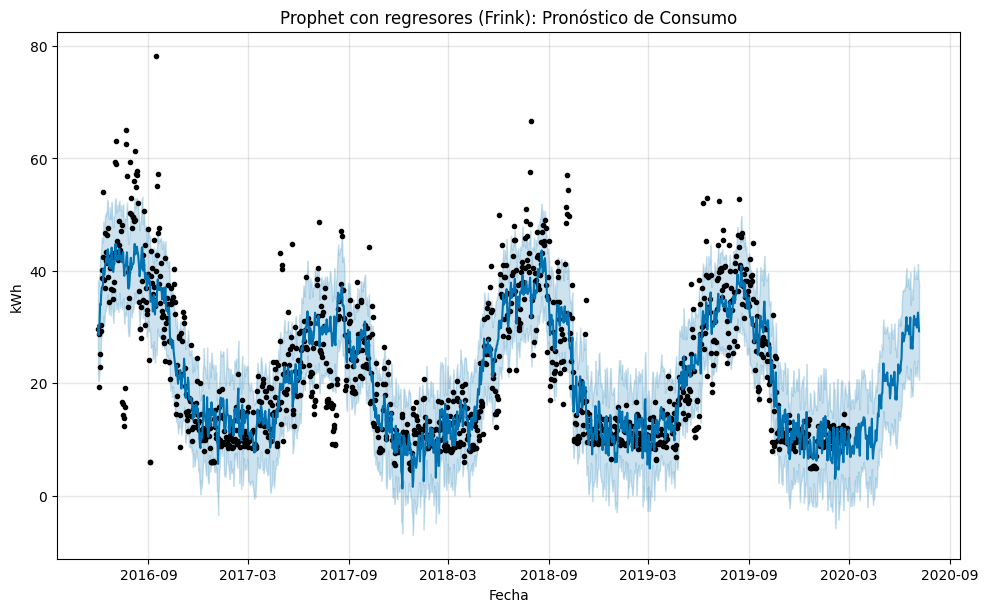

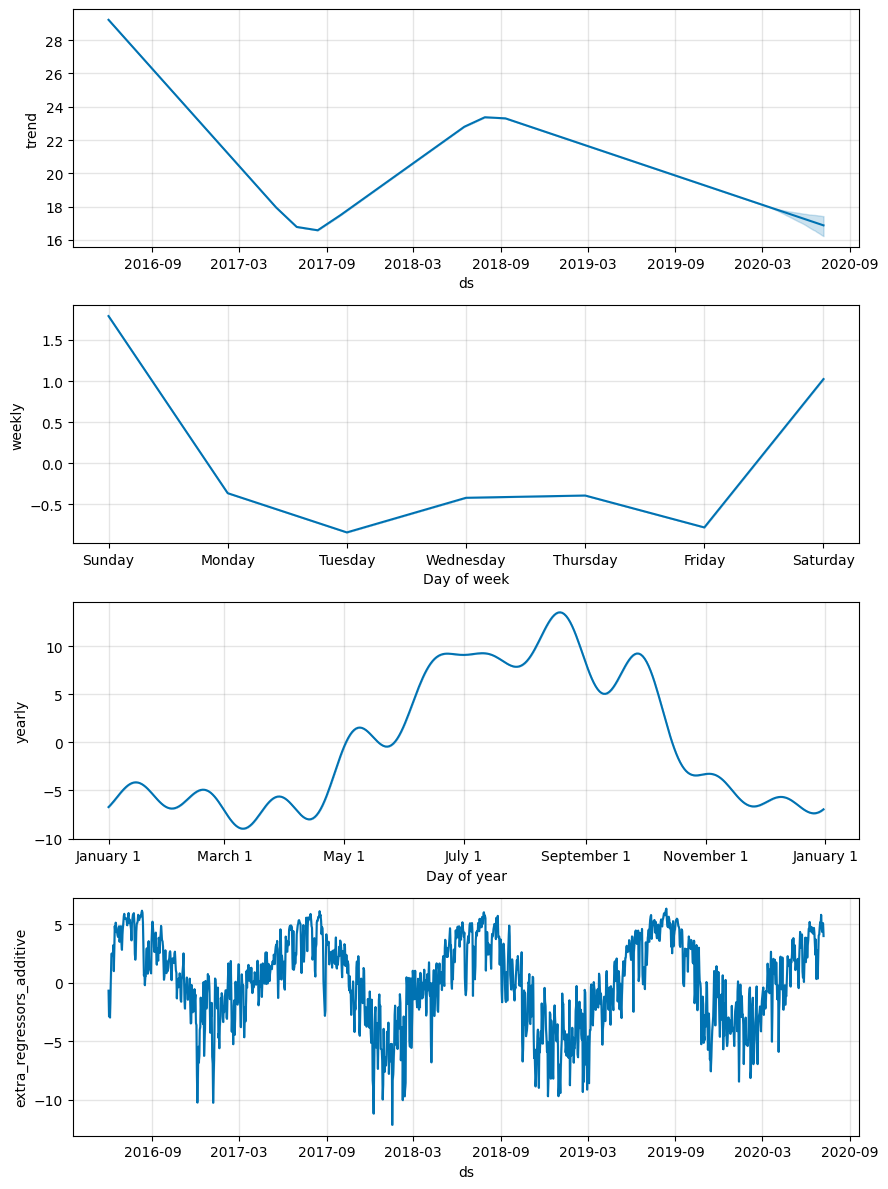

MAE (train): 4.720
MAE (test) : 4.524


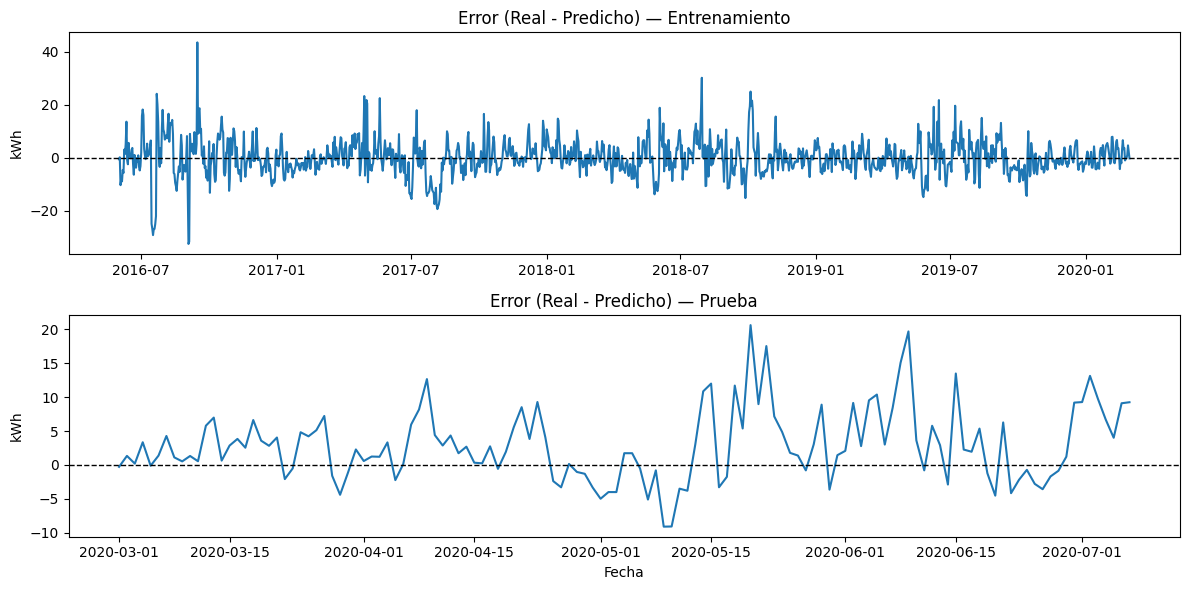

Autocorr residuos TRAIN (lag 7): 0.088
Autocorr residuos TRAIN (lag 30): 0.082
Autocorr residuos TRAIN (lag 365): -0.102
Autocorr residuos TEST  (lag 7): 0.099
Autocorr residuos TEST  (lag 30): -0.174
Autocorr residuos TEST  (lag 365): nan


In [9]:
#CODIGO AQUI
# =========================================================
# 0) Seleccionar exógenas y hacer merge en train/test
# =========================================================
# !pip install prophet --quiet

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- Carga consumo ---
df = pd.read_csv("energia_homero.csv", parse_dates=["date"])
df = (df
      .dropna(subset=["date", "Energy_kWh"])
      .drop_duplicates(subset=["date"])
      .sort_values("date")
      .reset_index(drop=True))

# Split temporal (igual que antes)
cutoff = pd.to_datetime("2020-02-29")
train = df[df["date"] <= cutoff].copy()
test  = df[df["date"] >= pd.to_datetime("2020-03-01")].copy()

# --- Carga clima (Frink) ---
met = pd.read_csv("datos_frink.csv", parse_dates=["date"]).sort_values("date")

# Selección de exógenas (promedios para reducir multicolinealidad)
exog_cols = ["Temp_avg", "Dew_avg", "Hum_avg", "Wind_avg", "Press_avg"]
use_cols  = ["date"] + exog_cols
met = met[use_cols]

# Merge por fecha en cada split (inner para asegurar pares completos)
train = train.merge(met, on="date", how="inner")
test  = test.merge(met, on="date", how="inner")

# (opcional) Si hubiese NaN después del merge, puedes imputar o descartar:
# train.dropna(subset=exog_cols, inplace=True)
# test.dropna(subset=exog_cols, inplace=True)

# Renombrar a formato Prophet (ds, y)
train = train.rename(columns={"date":"ds", "Energy_kWh":"y"})
test  = test.rename(columns={"date":"ds", "Energy_kWh":"y"})

# =========================================================
# 1) Crear Prophet, añadir regresores y entrenar
# =========================================================
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)
for r in exog_cols:
    # standardize='auto' normaliza internamente; prior_scale controla regularización del coeficiente
    m.add_regressor(r, standardize='auto', prior_scale=5.0)

# Entrenamiento con train (debe incluir ds, y y TODOS los regresores)
m.fit(train[["ds","y"] + exog_cols])

# =========================================================
# 2) Predicciones + gráficos Prophet
# =========================================================
# Predicciones en TEST (debes pasar también los regresores)
forecast_test = m.predict(test[["ds"] + exog_cols])

# Predicciones en TRAIN (para MAE de entrenamiento)
forecast_train = m.predict(train[["ds"] + exog_cols])

# Para graficar todo el intervalo (train+test) con Prophet.plot()
full_frame = pd.concat([
    train[["ds"] + exog_cols],
    test[["ds"] + exog_cols]
], ignore_index=True).sort_values("ds")
forecast_full = m.predict(full_frame)

# a) Curva de predicción completa
fig_pred = m.plot(forecast_full)
plt.title("Prophet con regresores (Frink): Pronóstico de Consumo"); plt.xlabel("Fecha"); plt.ylabel("kWh")
plt.show()

# b) Componentes: tendencia, estacionalidades y efectos de regresores
fig_comp = m.plot_components(forecast_full)
plt.show()

# =========================================================
# 3) MAE en train y test
# =========================================================
mae_train = mean_absolute_error(train["y"], forecast_train["yhat"])
mae_test  = mean_absolute_error(test["y"],  forecast_test["yhat"])
print(f"MAE (train): {mae_train:,.3f}")
print(f"MAE (test) : {mae_test:,.3f}")

# =========================================================
# 4) Residuos: gráfico y breve análisis
# =========================================================
# Residuos en train y en test
res_train = train["y"].to_numpy() - forecast_train["yhat"].to_numpy()
res_test  = test["y"].to_numpy()  - forecast_test["yhat"].to_numpy()

# Gráficos separados (train / test)
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)
axes[0].plot(train["ds"], res_train)
axes[0].axhline(0, ls="--", lw=1, c="k")
axes[0].set_title("Error (Real - Predicho) — Entrenamiento")
axes[0].set_ylabel("kWh")

axes[1].plot(test["ds"], res_test)
axes[1].axhline(0, ls="--", lw=1, c="k")
axes[1].set_title("Error (Real - Predicho) — Prueba")
axes[1].set_xlabel("Fecha"); axes[1].set_ylabel("kWh")
plt.tight_layout(); plt.show()

# (Opcional) chequeo simple de autocorrelación de residuos
def autocorr_at_lag(series, lag):
    s = pd.Series(series)
    return s.autocorr(lag) if len(s) > lag + 5 else np.nan

for lag in [7, 30, 365]:
    print(f"Autocorr residuos TRAIN (lag {lag}): {autocorr_at_lag(res_train, lag):.3f}")
for lag in [7, 30, 365]:
    print(f"Autocorr residuos TEST  (lag {lag}): {autocorr_at_lag(res_test, lag):.3f}")

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

In [10]:
!pip install prophet statsmodels --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


Lags seleccionados (umbral ±0.053):
  Temp_avg: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 15, 17, 19]
  Dew_avg: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 14, 18, 19]
  Hum_avg: [1, 2, 3, 4, 18, 19, 23]
  Wind_avg: [1, 3, 8, 11, 16, 24, 26]
  Press_avg: [1, 2, 3, 4, 5, 12, 18, 19, 21, 26, 27]


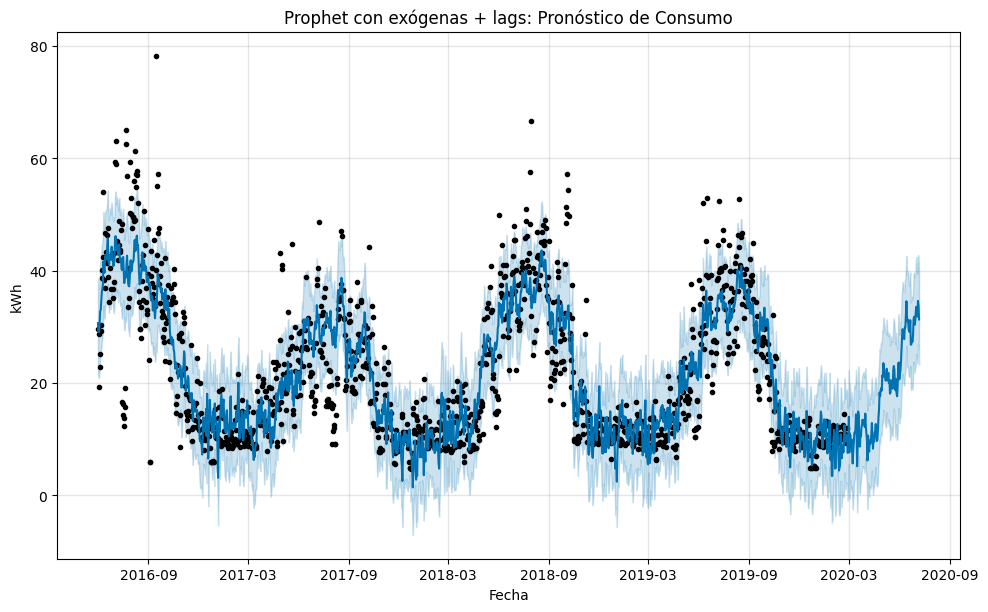

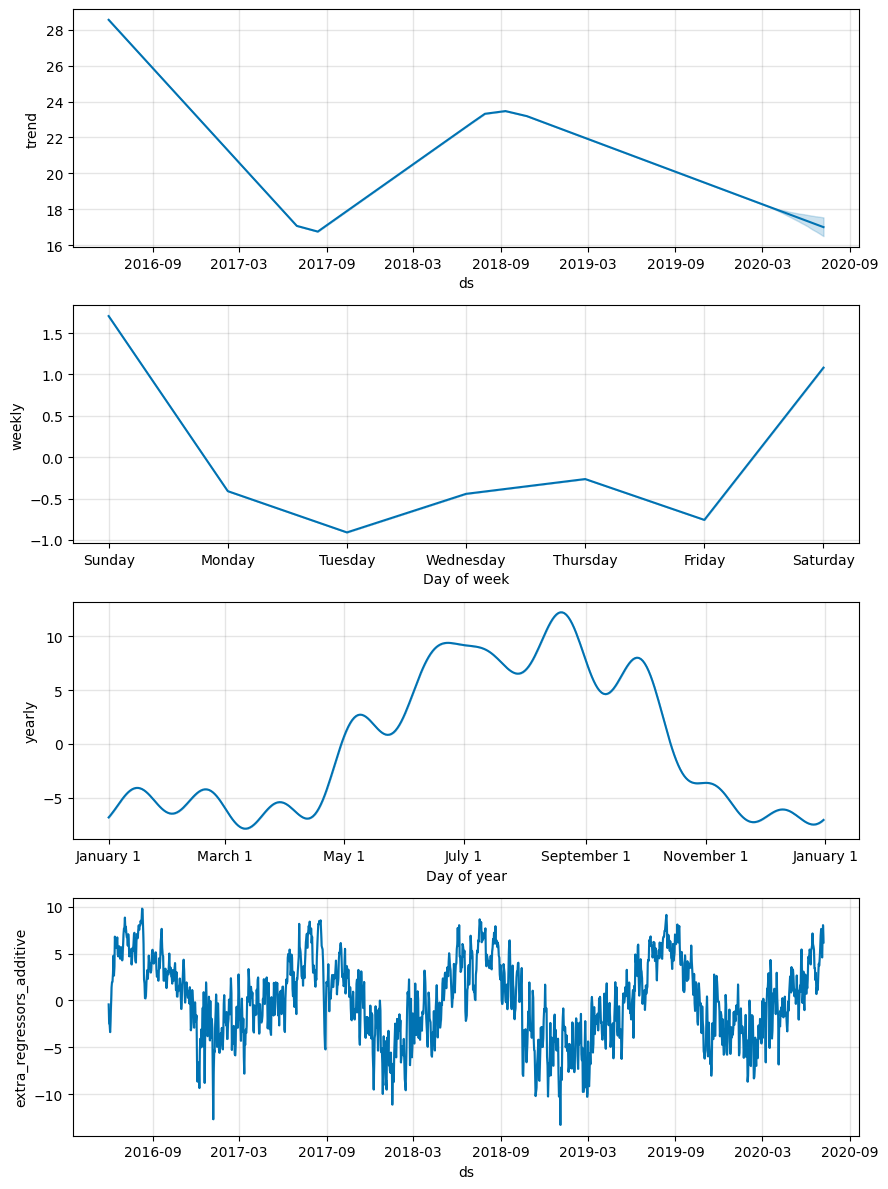

MAE (train): 4.648
MAE (test) : 4.530


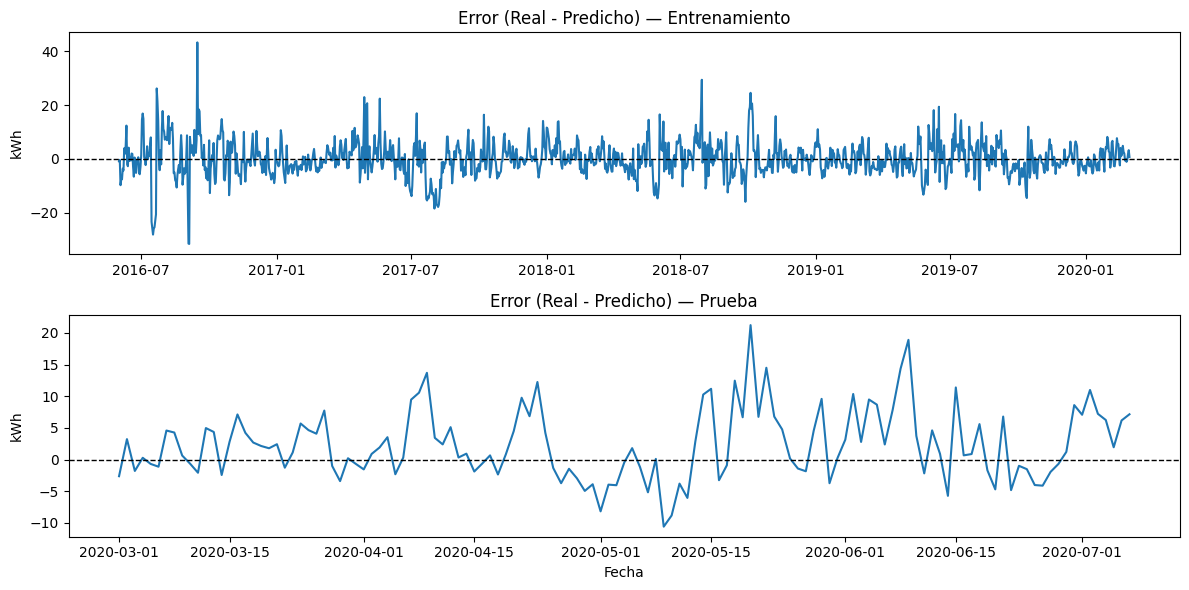

Autocorr residuos TRAIN (lag 7): 0.095
Autocorr residuos TRAIN (lag 30): 0.058
Autocorr residuos TRAIN (lag 365): -0.098
Autocorr residuos TEST  (lag 7): -0.011
Autocorr residuos TEST  (lag 30): -0.157
Autocorr residuos TEST  (lag 365): nan


In [12]:
#CODIGO AQUI
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# =========================================================
# 0) Carga, merge y split (reutiliza lo previo)
# =========================================================
df = pd.read_csv("energia_homero.csv", parse_dates=["date"]).sort_values("date")
df = df.dropna(subset=["date", "Energy_kWh"]).drop_duplicates(subset=["date"])

met = pd.read_csv("datos_frink.csv", parse_dates=["date"]).sort_values("date")

# Seleccionamos variables exógenas 'avg' (puedes ajustar)
exog_cols = ["Temp_avg", "Dew_avg", "Hum_avg", "Wind_avg", "Press_avg"]
met = met[["date"] + exog_cols].copy()

# Merge completo por fecha (para construir lags sin leakage)
full = df.merge(met, on="date", how="inner").sort_values("date").reset_index(drop=True)

# Split temporal
cutoff = pd.to_datetime("2020-02-29")
train_mask = full["date"] <= cutoff
test_mask  = full["date"] >= pd.to_datetime("2020-03-01")

full.rename(columns={"date":"ds", "Energy_kWh":"y"}, inplace=True)

train_base = full.loc[train_mask, ["ds", "y"] + exog_cols].copy()
test_base  = full.loc[test_mask,  ["ds", "y"] + exog_cols].copy()

# =========================================================
# 1) PACF de exógenas (en TRAIN) y selección de lags por significancia
#    Criterio: |PACF(lag)| > 1.96/sqrt(N) (aprox banda 95%)
#    Máx lag considerado: 30
# =========================================================
from statsmodels.tsa.stattools import pacf

max_lag = 30
N = len(train_base)
sig = 1.96 / np.sqrt(N)  # umbral ~95%

selected_lags = {}

for col in exog_cols:
    # Serie limpia (sin NaN) para PACF
    x = (train_base[col]
         .astype(float)
         .interpolate()
         .bfill()
         .ffill()
         .to_numpy())

    # nlags seguro (pacf exige nlags < nobs-1)
    nlags = max(1, min(max_lag, len(x) - 2))

    # ✅ método válido en statsmodels recientes (equivale al "unbiased" que querías)
    pacf_vals = pacf(x, nlags=nlags, method="ywadjusted")

    # Selección por significancia
    chosen = [lag for lag in range(1, nlags + 1) if abs(pacf_vals[lag]) > sig]
    if not chosen:
        chosen = [1]  # fallback razonable

    selected_lags[col] = chosen

print("Lags seleccionados (umbral ±{:.3f}):".format(sig))
for k, v in selected_lags.items():
    print(f"  {k}: {v}")
# Justificación:
# - Usamos PACF en TRAIN para detectar memoria propia de cada exógena.
# - Incluimos los lags cuyo PACF es significativo (|PACF| > 1.96/sqrt(N)).
# - Si ninguno supera el umbral, aseguramos lag 1 como heurística mínima.

# =========================================================
# 2) Construcción de columnas de lags (en todo el FULL, luego split)
# =========================================================
def add_lags(df_in, cols, lag_map):
    df_out = df_in.copy()
    df_out = df_out.sort_values("ds").reset_index(drop=True)
    for c in cols:
        for L in lag_map[c]:
            df_out[f"{c}_lag{L}"] = df_out[c].shift(L)
    return df_out

full_with_lags = add_lags(full[["ds", "y"] + exog_cols], exog_cols, selected_lags)

train = full_with_lags.loc[train_mask].copy()
test  = full_with_lags.loc[test_mask].copy()

# =========================================================
# 3) Imputación de NaNs en lags con la media (usando medias de TRAIN)
# =========================================================
lag_cols = [c for c in full_with_lags.columns if any(c.startswith(ec+"_lag") for ec in exog_cols)]

# medias de TRAIN por variable lag (para evitar fuga de información)
lag_means = train[lag_cols].mean(numeric_only=True)
train[lag_cols] = train[lag_cols].fillna(lag_means)
test[lag_cols]  = test[lag_cols].fillna(lag_means)

# (Si alguna exógena original tuviera NaNs, también podrías imputar igual)
# train[exog_cols] = train[exog_cols].fillna(train[exog_cols].mean())
# test[exog_cols]  = test[exog_cols].fillna(train[exog_cols].mean())

# =========================================================
# 4) Prophet con exógenas + lags
# =========================================================
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

# Añadimos como regresores tanto las exógenas originales como sus lags
for r in exog_cols + lag_cols:
    m.add_regressor(r, standardize='auto', prior_scale=5.0)

# Entrenar (Prophet exige que estén todas las columnas)
fit_cols = ["ds", "y"] + exog_cols + lag_cols
m.fit(train[fit_cols])

# =========================================================
# 5) Predicciones + gráficos Prophet (predicción y componentes)
#    Para los gráficos de Prophet, predecimos en todo el intervalo disponible.
# =========================================================
# DataFrame con todo el intervalo (train+test) y todas las features
full_for_pred = pd.concat([train[["ds"] + exog_cols + lag_cols],
                           test[["ds"] + exog_cols + lag_cols]],
                          ignore_index=True).sort_values("ds")

forecast_full = m.predict(full_for_pred)

# a) Curva de predicción completa
fig_pred = m.plot(forecast_full)
plt.title("Prophet con exógenas + lags: Pronóstico de Consumo"); plt.xlabel("Fecha"); plt.ylabel("kWh")
plt.show()

# b) Componentes (tendencia, estacionalidades y regresores/lags)
fig_comp = m.plot_components(forecast_full)
plt.show()

# =========================================================
# 6) MAE en TRAIN y TEST
# =========================================================
# Predicción alineada para train
forecast_train = m.predict(train[["ds"] + exog_cols + lag_cols])
forecast_test  = m.predict(test[["ds"]  + exog_cols + lag_cols])

mae_train = mean_absolute_error(train["y"], forecast_train["yhat"])
mae_test  = mean_absolute_error(test["y"],  forecast_test["yhat"])

print(f"MAE (train): {mae_train:,.3f}")
print(f"MAE (test) : {mae_test:,.3f}")

# =========================================================
# 7) Residuos y análisis
# =========================================================
res_train = train["y"].to_numpy() - forecast_train["yhat"].to_numpy()
res_test  = test["y"].to_numpy()  - forecast_test["yhat"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)
axes[0].plot(train["ds"], res_train)
axes[0].axhline(0, ls="--", lw=1, c="k")
axes[0].set_title("Error (Real - Predicho) — Entrenamiento")
axes[0].set_ylabel("kWh")

axes[1].plot(test["ds"], res_test)
axes[1].axhline(0, ls="--", lw=1, c="k")
axes[1].set_title("Error (Real - Predicho) — Prueba")
axes[1].set_xlabel("Fecha"); axes[1].set_ylabel("kWh")
plt.tight_layout(); plt.show()

# (Opcional) Autocorrelación simple en lags estacionales de los residuos
def autocorr_at_lag(series, lag):
    s = pd.Series(series)
    return s.autocorr(lag) if len(s) > lag + 5 else np.nan

for lag in [7, 30, 365]:
    print(f"Autocorr residuos TRAIN (lag {lag}): {autocorr_at_lag(res_train, lag):.3f}")
for lag in [7, 30, 365]:
    print(f"Autocorr residuos TEST  (lag {lag}): {autocorr_at_lag(res_test, lag):.3f}")

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [14]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

Features usadas: ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']


Tuning Prophet parameters: 100%|██████████| 48/48 [00:20<00:00,  2.32it/s]


=== TOP 5 resultados ===


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,MAEs
24,0.5,5.0,additive,0.8,4.030463
28,0.5,10.0,additive,0.8,4.036483
36,1.0,5.0,additive,0.8,4.043057
40,1.0,10.0,additive,0.8,4.049485
44,1.0,20.0,additive,0.8,4.072457



=== Mejores parámetros ===
{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'changepoint_range': 0.8}


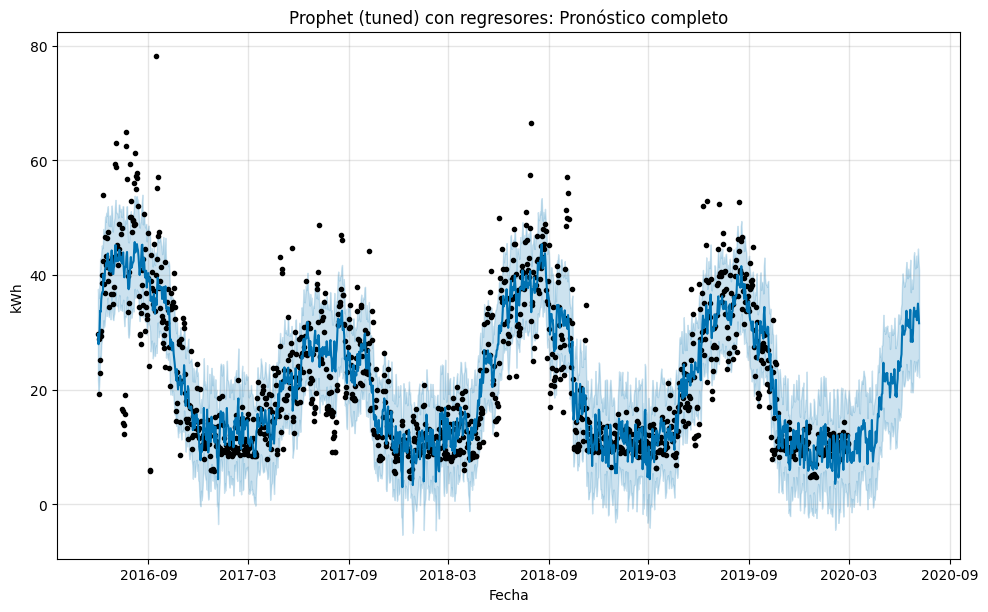

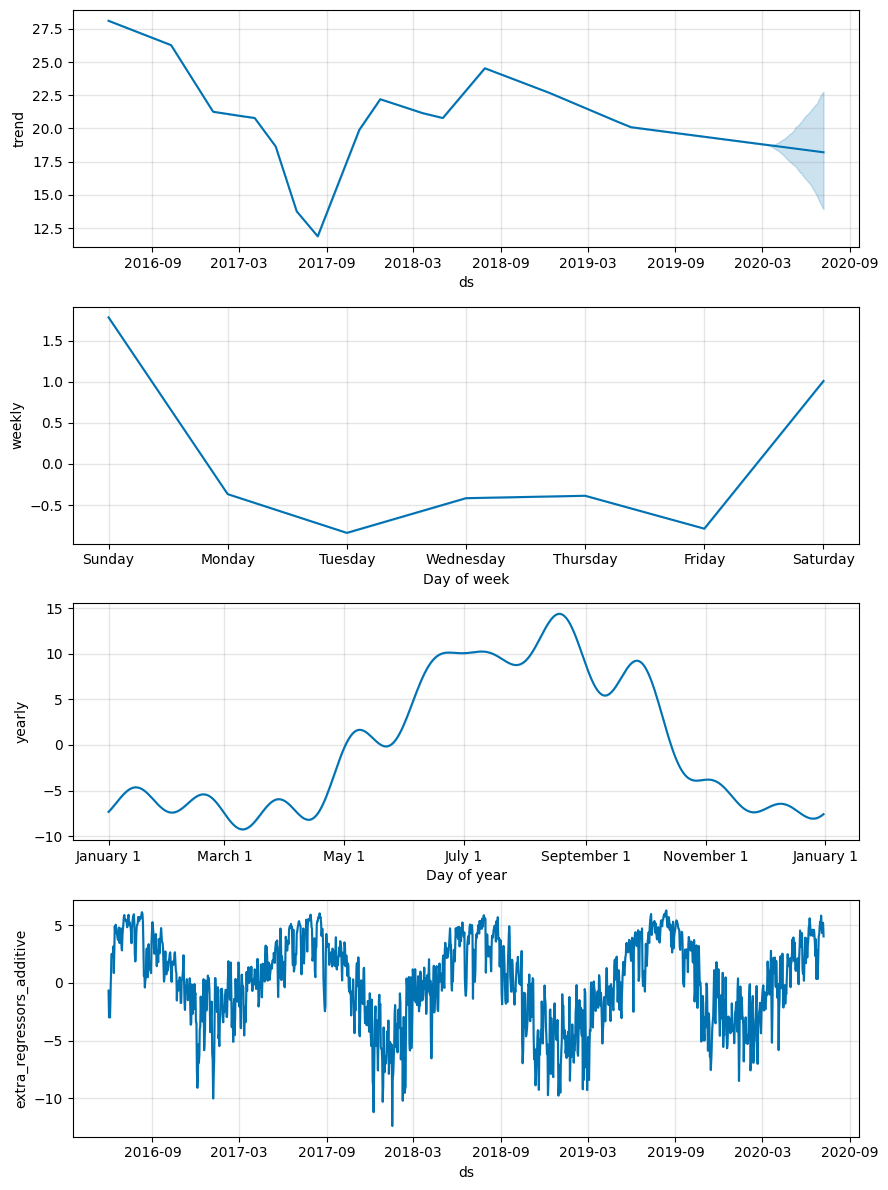


MAE (train): 4.568
MAE (test) : 4.138


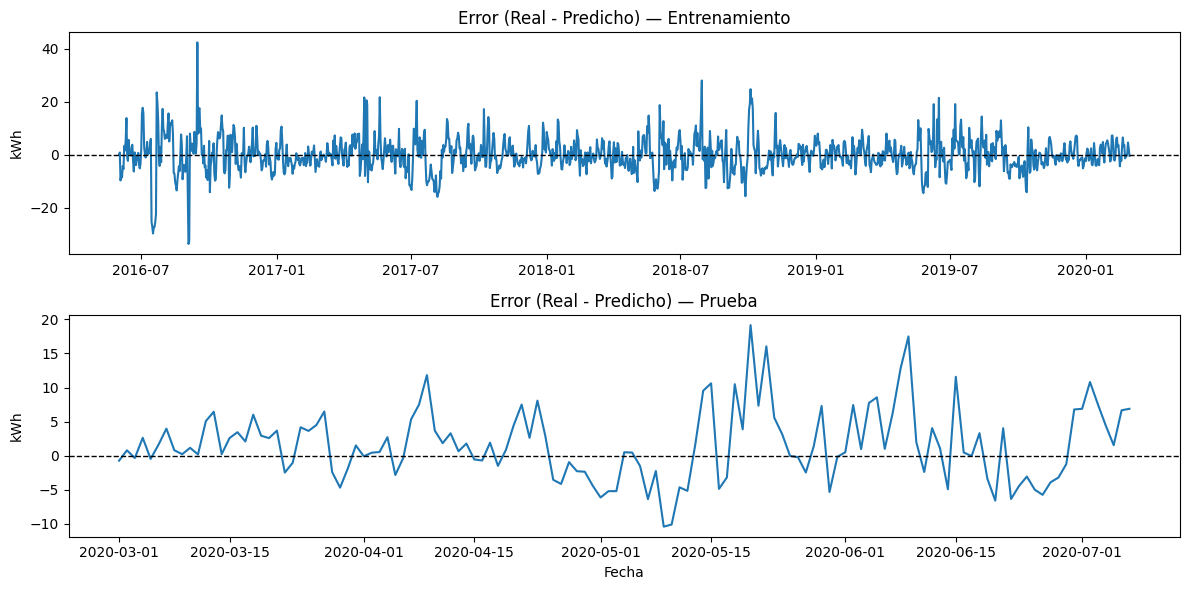

In [15]:
#CODIGO AQUI
# ============================================================
# 0) (Opcional) Reconstruir train/test con exógenos (y lags si existen)
#     Si ya los tienes, puedes saltarte este bloque y seguir en el (1).
# ============================================================
import pandas as pd
import numpy as np

# Cargar consumo
df = pd.read_csv("energia_homero.csv", parse_dates=["date"]).sort_values("date")
df = df.dropna(subset=["date", "Energy_kWh"]).drop_duplicates(subset=["date"])

# Cargar clima
met = pd.read_csv("datos_frink.csv", parse_dates=["date"]).sort_values("date")

# Exógenas base (ajústalo si usaste otras)
exog_cols = ["Temp_avg", "Dew_avg", "Hum_avg", "Wind_avg", "Press_avg"]
met = met[["date"] + exog_cols]

# Merge
full = df.merge(met, on="date", how="inner").sort_values("date").reset_index(drop=True)

# Si anteriormente creaste lags, los vuelves a generar aquí (opcional):
# from statsmodels.tsa.stattools import pacf
# ... (tu lógica de lags) ...
# full = full_con_lags

# Renombrar para Prophet
full = full.rename(columns={"date":"ds", "Energy_kWh":"y"})

# Split temporal
cutoff = pd.to_datetime("2020-02-29")
train = full[full["ds"] <= cutoff].copy().sort_values("ds").reset_index(drop=True)
test  = full[full["ds"] >= pd.to_datetime("2020-03-01")].copy().sort_values("ds").reset_index(drop=True)

# Detectar automáticamente TODAS las features (exógenas + lags si existen)
feature_cols = [c for c in train.columns if c not in ("ds","y")]

# Imputación simple por si quedaron NaN (usa medias de train para evitar leakage)
train[feature_cols] = train[feature_cols].fillna(train[feature_cols].mean(numeric_only=True))
test[feature_cols]  = test[feature_cols].fillna(train[feature_cols].mean(numeric_only=True))

print("Features usadas:", feature_cols)


# ============================================================
# 1) GRID de hiperparámetros y optimización con optimize_prophet()
#    (Usa la celda NO-MODIFICAR que ya tienes definida)
# ============================================================
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Grilla razonable (ajusta tamaños si quieres más/menos tiempo de cómputo)
param_grid = {
    "changepoint_prior_scale": [0.05, 0.1, 0.5, 1.0],   # suavidad de la tendencia
    "seasonality_prior_scale": [5.0, 10.0, 20.0],       # regularización de estacionalidad
    "seasonality_mode": ["additive", "multiplicative"], # modo estacional
    "changepoint_range": [0.8, 0.9]                     # fracción inicial con posibles changepoints
}

# IMPORTANTE: la función optimize_prophet espera dataframes con ds, y y las features
train_opt = train[["ds","y"] + feature_cols].copy()
test_opt  = test[["ds","y"] + feature_cols].copy()

tuning_results, best_params = optimize_prophet(
    df=train_opt,
    df_to_pred=test_opt,
    features=feature_cols,
    param_grid=param_grid
)

print("\n=== TOP 5 resultados ===")
display(tuning_results.head())
print("\n=== Mejores parámetros ===")
print(best_params)


# ============================================================
# 2) Entrenar Prophet con los MEJORES parámetros + regresores
# ============================================================
m_best = Prophet(**best_params,
                 weekly_seasonality=True,   # mantenemos semanal
                 daily_seasonality=False)   # y sin diaria para datos diarios

# Agregar TODOS los regresores detectados (exógenos + lags si están)
for f in feature_cols:
    m_best.add_regressor(f, standardize='auto', prior_scale=5.0)

m_best.fit(train_opt)  # contiene ds, y y TODAS las features


# ============================================================
# 3) Gráficos: predicciones y componentes
#    (Predicción en todo el rango train+test para plot)
# ============================================================
# Prophet necesita un dataframe "future" con ds y las mismas features en el mismo orden
future_full = pd.concat(
    [train_opt[["ds"] + feature_cols], test_opt[["ds"] + feature_cols]],
    ignore_index=True
).sort_values("ds").reset_index(drop=True)

forecast_full = m_best.predict(future_full)

# Plot 1: curva de pronóstico completa
import matplotlib.pyplot as plt
fig1 = m_best.plot(forecast_full)
plt.title("Prophet (tuned) con regresores: Pronóstico completo"); plt.xlabel("Fecha"); plt.ylabel("kWh")
plt.show()

# Plot 2: componentes (tendencia, estacionalidades y regresores)
fig2 = m_best.plot_components(forecast_full)
plt.show()


# ============================================================
# 4) MAE en TRAIN y TEST
# ============================================================
# Predicciones alineadas a cada conjunto
forecast_train = m_best.predict(train_opt[["ds"] + feature_cols])
forecast_test  = m_best.predict(test_opt[["ds"] + feature_cols])

mae_train = mean_absolute_error(train_opt["y"], forecast_train["yhat"])
mae_test  = mean_absolute_error(test_opt["y"],  forecast_test["yhat"])

print(f"\nMAE (train): {mae_train:,.3f}")
print(f"MAE (test) : {mae_test:,.3f}")


# ============================================================
# 5) Residuos: gráfico y breve lectura
# ============================================================
res_train = train_opt["y"].to_numpy() - forecast_train["yhat"].to_numpy()
res_test  = test_opt["y"].to_numpy()  - forecast_test["yhat"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)
axes[0].plot(train_opt["ds"], res_train)
axes[0].axhline(0, ls="--", lw=1, c="k")
axes[0].set_title("Error (Real - Predicho) — Entrenamiento")
axes[0].set_ylabel("kWh")

axes[1].plot(test_opt["ds"], res_test)
axes[1].axhline(0, ls="--", lw=1, c="k")
axes[1].set_title("Error (Real - Predicho) — Prueba")
axes[1].set_xlabel("Fecha"); axes[1].set_ylabel("kWh")
plt.tight_layout(); plt.show()

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [16]:
!pip install surprise

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-macosx_10_13_universal2.whl size=975751 sha256=bcc9555ece1310915cdb579a5700170b4e0ada67e5c3c393105136f67f019fc9
  Stored in directory: /Users/matiasgodoy/Library/Caches/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [surprise]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [18]:
#CODIGO AQUI
# --- Carga y exploración básica ---
import pandas as pd
import numpy as np

# 1) Cargar datos
df = pd.read_csv("cervezas.csv")

# 2) Normalizar nombres de columnas por si vienen con mayúsculas/espacios
df.columns = df.columns.str.strip()
expected = {"userId","beerId","rating","beerName","beerStyle"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas esperadas: {missing}")

# 3) Tipos sugeridos (sin forzar si hay valores mixtos)
#    Si userId/beerId no son numéricos, se mantienen como string
for col in ["userId","beerId"]:
    try:
        df[col] = pd.to_numeric(df[col], errors="raise")
    except Exception:
        df[col] = df[col].astype(str)

# 4) Resumen general
print("Shape (filas, columnas):", df.shape)
print("\nPrimeras filas:")
display(df.head(3))

# 5) ¿Hay valores nulos?
nulls = df.isna().sum().sort_values(ascending=False)
nulls_pct = (df.isna().mean()*100).round(2)
print("\nValores nulos por columna:")
display(pd.DataFrame({"nulos": nulls, "%": nulls_pct}).T)

# 6) ¿Cuántas cervezas y cuántos usuarios?
n_beers = df["beerId"].nunique(dropna=True)
n_users = df["userId"].nunique(dropna=True)
print(f"\n👉 Cervezas evaluadas (beerId únicos): {n_beers}")
print(f"👉 Ciudadanos que evaluaron (userId únicos): {n_users}")

# 7) Revisión de rating
print("\nResumen rating:")
display(df["rating"].describe())

# ¿Fuera de rango [1, 5]?
out_of_range = df[(df["rating"] < 1.0) | (df["rating"] > 5.0)]
print(f"Ratings fuera de [1,5]: {len(out_of_range)}")
if len(out_of_range) > 0:
    display(out_of_range.head())

# 8) Duplicados por (userId, beerId) (múltiples valoraciones de la misma cerveza por el mismo usuario)
dup_pairs = df.duplicated(subset=["userId","beerId"], keep=False)
print(f"\nPares (userId, beerId) con múltiples registros: {dup_pairs.sum()} filas")
if dup_pairs.any():
    (df.loc[dup_pairs]
       .groupby(["userId","beerId"])
       .size()
       .reset_index(name="n_ratings")
       .query("n_ratings > 1")
       .head(10)
       .pipe(display))

# 9) (Opcional) Top estilos y cervezas más evaluadas
print("\nTop 10 cervezas por cantidad de evaluaciones:")
top_beers = (df.groupby(["beerId","beerName"])
               .size()
               .reset_index(name="n_ratings")
               .sort_values("n_ratings", ascending=False)
               .head(10))
display(top_beers)

print("\nDistribución de estilos (top 10):")
top_styles = (df["beerStyle"]
                .value_counts()
                .head(10)
                .rename_axis("beerStyle")
                .reset_index(name="count"))
display(top_styles)

Shape (filas, columnas): (295059, 5)

Primeras filas:


,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA



Valores nulos por columna:


,userId,beerId,rating,beerName,beerStyle
nulos,0.0,0.0,0.0,0.0,0.0
%,0.0,0.0,0.0,0.0,0.0



👉 Cervezas evaluadas (beerId únicos): 3747
👉 Ciudadanos que evaluaron (userId únicos): 706

Resumen rating:


...

,userId,beerId,n_ratings
0,1,429,329
1,3,5,100
2,3,6,230
3,3,7,146
4,3,9,23
5,3,1565,76
6,3,2999,22
7,3,3000,21
8,3,3001,42
9,3,23505,69



Top 10 cervezas por cantidad de evaluaciones:


,beerId,beerName,n_ratings
828,2093,90 Minute IPA,809
225,412,Old Rasputin Russian Imperial Stout,800
776,1904,Sierra Nevada Celebration Ale,731
1213,4083,Stone Ruination IPA,670
486,1093,Two Hearted Ale,660
47,92,Arrogant Bastard Ale,658
44,88,Stone IPA (India Pale Ale),647
1646,11757,Founders Breakfast Stout,643
149,276,Sierra Nevada Pale Ale,637
1367,6108,60 Minute IPA,623



Distribución de estilos (top 10):


,beerStyle,count
0,American IPA,23138
1,American Double / Imperial IPA,18616
2,Russian Imperial Stout,11732
3,American Double / Imperial Stout,10783
4,American Pale Ale (APA),10430
5,American Porter,9303
6,Belgian Strong Dark Ale,7893
7,American Amber / Red Ale,7720
8,American Strong Ale,6653
9,Belgian Strong Pale Ale,6196


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

========== Resumen de datos ==========
Usuarios únicos: 706
Productos (cervezas) únicos: 3747
Calificaciones registradas (filas): 295059
Calificaciones con rating nulo (NaN): 0

--- Visión de matriz ---
Celdas posibles en matriz user×item: 2,645,382
Celdas observadas (pares únicos con rating): 3,747
Celdas faltantes en matriz: 2,641,635
Sparsity (proporción de celdas faltantes): 0.9986

--- Medias ---
Media global de ratings: 3.860
Media de rating por usuario (primeras filas):
   userId  mean_rating_user
0       1          3.834347
1       3          3.565199
2       4          4.044580
3       5          3.837662
4       6          3.871951

Media de rating por producto (primeras filas):
   beerId             beerName  mean_rating_item
0       5                Amber          3.395000
1       6             Turbodog          3.765217
2       7          Purple Haze          3.256849
3       9               Golden          3.478261
4      10  Allagash Dubbel Ale          3.791908


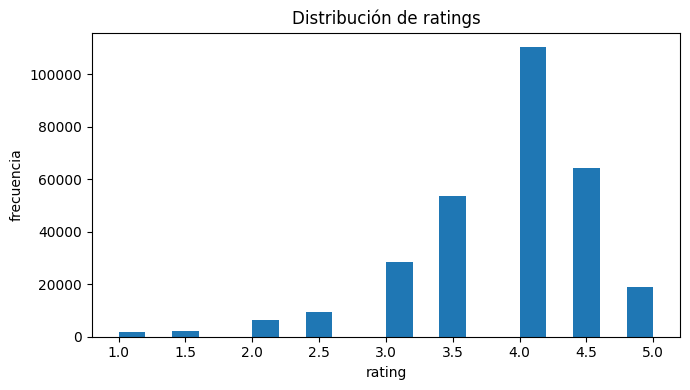

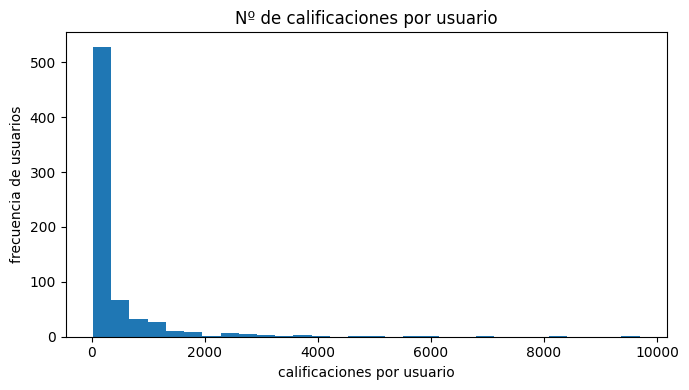

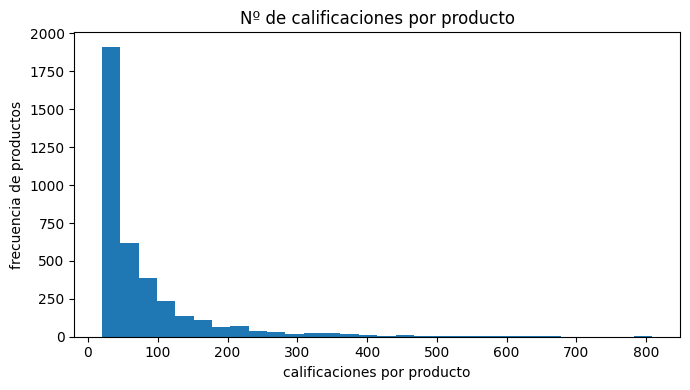

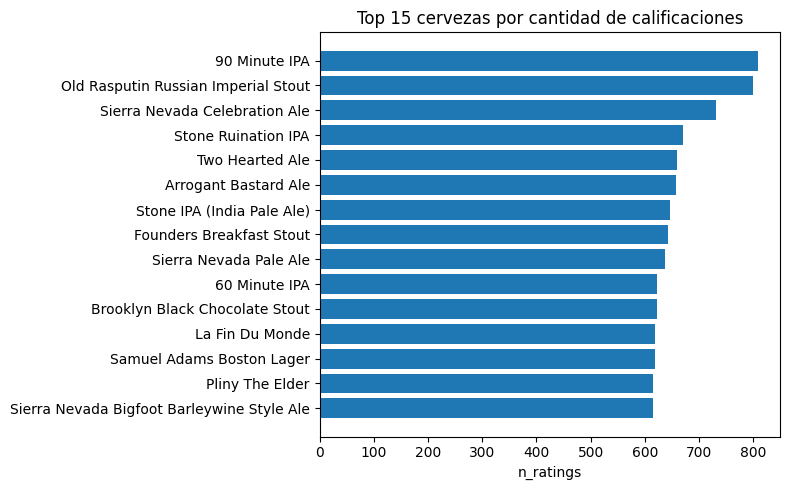

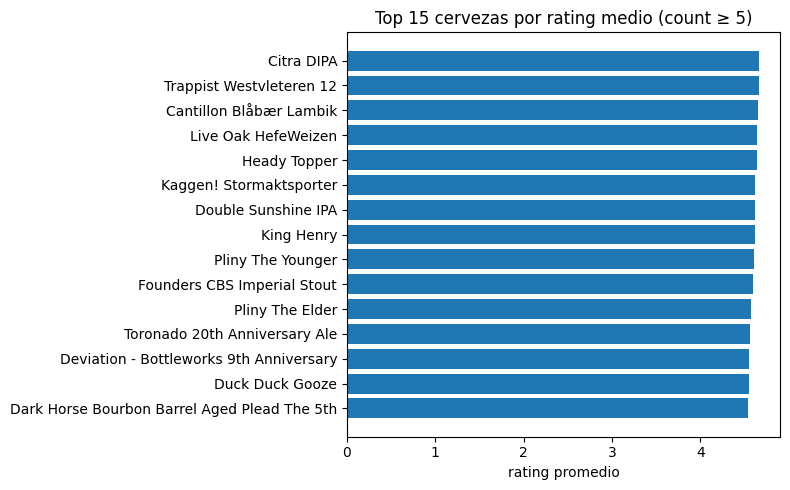

In [19]:
# ===============================================
# 1) Carga + estadística descriptiva + gráficos
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Cargar dataset
df = pd.read_csv("cervezas.csv")
df.columns = df.columns.str.strip()

# sanity check de columnas esperadas
required = {"userId","beerId","rating","beerName","beerStyle"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

# Tipos sugeridos (si vienen como string no pasa nada)
for c in ["userId","beerId"]:
    try:
        df[c] = pd.to_numeric(df[c], errors="raise")
    except Exception:
        df[c] = df[c].astype(str)

# Asegurar rating como float
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# --- Métricas base ---
n_users   = df["userId"].nunique(dropna=True)
n_items   = df["beerId"].nunique(dropna=True)
n_rows    = len(df)                         # calificaciones registradas (filas)
n_null_r  = df["rating"].isna().sum()      # NaN en rating

# Conteo de pares únicos (user, item) con rating válido
valid_pairs = (df.dropna(subset=["rating"])
                 .drop_duplicates(subset=["userId","beerId"]))
n_filled_matrix = len(valid_pairs)          # celdas efectivamente observadas (únicas)
n_possible      = n_users * n_items         # tamaño total de la matriz
n_missing_matrix = n_possible - n_filled_matrix
sparsity = 1 - (n_filled_matrix / n_possible) if n_possible > 0 else np.nan

# --- Medias de rating ---
overall_mean = df["rating"].mean()
mean_by_user = df.groupby("userId", as_index=False)["rating"].mean().rename(columns={"rating":"mean_rating_user"})
mean_by_item = (df.groupby(["beerId","beerName"], as_index=False)["rating"]
                  .mean().rename(columns={"rating":"mean_rating_item"}))

print("========== Resumen de datos ==========")
print(f"Usuarios únicos: {n_users}")
print(f"Productos (cervezas) únicos: {n_items}")
print(f"Calificaciones registradas (filas): {n_rows}")
print(f"Calificaciones con rating nulo (NaN): {n_null_r}")
print("\n--- Visión de matriz ---")
print(f"Celdas posibles en matriz user×item: {n_possible:,}")
print(f"Celdas observadas (pares únicos con rating): {n_filled_matrix:,}")
print(f"Celdas faltantes en matriz: {n_missing_matrix:,}")
print(f"Sparsity (proporción de celdas faltantes): {sparsity:.4f}")
print("\n--- Medias ---")
print(f"Media global de ratings: {overall_mean:.3f}")
print("Media de rating por usuario (primeras filas):")
print(mean_by_user.head())
print("\nMedia de rating por producto (primeras filas):")
print(mean_by_item.head())

# --- Gráficos (uno por figura) ---
# 1) Distribución de ratings
plt.figure(figsize=(7,4))
df["rating"].dropna().plot(kind="hist", bins=20)
plt.title("Distribución de ratings")
plt.xlabel("rating"); plt.ylabel("frecuencia")
plt.tight_layout(); plt.show()

# 2) Nº de ratings por usuario (cola larga)
cnt_by_user = df.groupby("userId").size()
plt.figure(figsize=(7,4))
cnt_by_user.plot(kind="hist", bins=30)
plt.title("Nº de calificaciones por usuario")
plt.xlabel("calificaciones por usuario"); plt.ylabel("frecuencia de usuarios")
plt.tight_layout(); plt.show()

# 3) Nº de ratings por producto
cnt_by_item = df.groupby(["beerId"]).size()
plt.figure(figsize=(7,4))
cnt_by_item.plot(kind="hist", bins=30)
plt.title("Nº de calificaciones por producto")
plt.xlabel("calificaciones por producto"); plt.ylabel("frecuencia de productos")
plt.tight_layout(); plt.show()

# 4) Top 15 productos por cantidad de ratings (para ver concentración)
top_items = (df.groupby(["beerId","beerName"])
               .size()
               .reset_index(name="n_ratings")
               .sort_values("n_ratings", ascending=False)
               .head(15))
plt.figure(figsize=(8,5))
plt.barh(top_items["beerName"][::-1], top_items["n_ratings"][::-1])
plt.title("Top 15 cervezas por cantidad de calificaciones")
plt.xlabel("n_ratings"); plt.tight_layout(); plt.show()

# 5) Top 15 productos por rating medio (con al menos 5 ratings)
min_count = 5
item_stats = (df.groupby(["beerId","beerName"])["rating"]
                .agg(["mean","count"])
                .reset_index())
item_stats = item_stats[item_stats["count"] >= min_count].sort_values("mean", ascending=False).head(15)
plt.figure(figsize=(8,5))
plt.barh(item_stats["beerName"][::-1], item_stats["mean"][::-1])
plt.title(f"Top 15 cervezas por rating medio (count ≥ {min_count})")
plt.xlabel("rating promedio"); plt.tight_layout(); plt.show()

In [20]:
# ===============================================
# 2) Matriz usuario-producto
# ===============================================

# Si un usuario evaluó varias veces la misma cerveza, promediamos
R = pd.pivot_table(
    df,
    index="userId",
    columns="beerId",
    values="rating",
    aggfunc="mean"   # o 'max', 'last', según tu criterio
)

print("Shape de la matriz R (usuarios × productos):", R.shape)
print("\nVista parcial de la matriz:")
print(R.iloc[:10, :10])  # submatriz pequeña para ver

# (Opcional) guardar para el modelo
# R.to_csv("matriz_usuario_producto.csv", index=True)

Shape de la matriz R (usuarios × productos): (706, 3747)

Vista parcial de la matriz:
beerId     5         6         7         9         10        11        14  15  \
userId                                                                          
1         NaN       NaN       NaN       NaN       NaN       NaN       NaN NaN   
3       3.395  3.765217  3.256849  3.478261       NaN       NaN       NaN NaN   
4         NaN       NaN       NaN       NaN  3.791908       NaN       NaN NaN   
5         NaN       NaN       NaN       NaN       NaN  3.431818       NaN NaN   
6         NaN       NaN       NaN       NaN       NaN       NaN  3.892157 NaN   
8         NaN       NaN       NaN       NaN       NaN       NaN       NaN NaN   
9         NaN       NaN       NaN       NaN       NaN       NaN       NaN NaN   
14        NaN       NaN       NaN       NaN       NaN       NaN       NaN NaN   
18        NaN       NaN       NaN       NaN       NaN       NaN       NaN NaN   
20        NaN       NaN

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [21]:
#CODIGO AQUI
# =========================================================
# 0) Carga
# =========================================================
import pandas as pd
import numpy as np

df = pd.read_csv("cervezas.csv")
df.columns = df.columns.str.strip()

required = {"userId","beerId","rating","beerName","beerStyle"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

# Tipos (si vienen como string, los dejamos como están)
for c in ["userId","beerId"]:
    try:
        df[c] = pd.to_numeric(df[c], errors="raise")
    except Exception:
        df[c] = df[c].astype(str)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# =========================================================
# 1) DataFrame con características de cervezas (sin ratings)
#    - Un registro por beerId (sin duplicados)
# =========================================================
# Si hay varias filas por beerId con mismos meta-datos, nos quedamos con la primera
df_beers = (df[["beerId","beerName","beerStyle"]]
            .drop_duplicates(subset=["beerId"])
            .reset_index(drop=True))

print("✅ DataFrame de características (sin ratings):", df_beers.shape)
display(df_beers.head(10))

# =========================================================
# 2) Bag of Words sobre beerStyle
#    - minúsculas (default)
#    - stopwords en inglés
#    - min_df=10 (palabra debe aparecer en ≥10 cervezas)
#    Guardar resultado como DataFrame
# =========================================================
from sklearn.feature_extraction.text import CountVectorizer

# Reemplazar NaN por string vacío para vectorizar
styles = df_beers["beerStyle"].fillna("")

vectorizer = CountVectorizer(lowercase=True, stop_words="english", min_df=10)
X = vectorizer.fit_transform(styles)  # matriz (n_beers × vocab)
vocab = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(X.toarray(), index=df_beers["beerId"], columns=vocab)
print("✅ Bag of Words (beerStyle) con min_df=10:", bow_df.shape)
display(bow_df.head(5))

# =========================================================
# 3) Función: top-5 cervezas similares por coseno a un beerName dado
#    (usa solo Bag of Words de estilos)
# =========================================================
from sklearn.metrics.pairwise import cosine_similarity

# Mapa auxiliar: beerId -> beerName y beerName -> ids (por si hay duplicados de nombre)
id_to_name = df_beers.set_index("beerId")["beerName"].to_dict()
name_to_ids = (df_beers.groupby("beerName")["beerId"]
               .apply(list).to_dict())

def top5_similares_por_nombre(beer_name, topn=5):
    """
    Busca por nombre (case-insensitive, permite match exacto o 'contiene'),
    calcula similitud coseno sobre la matriz BoW y devuelve top-N similares.
    Excluye la cerveza consultada.
    """
    # 1) Resolver beerId(s) candidatos para el nombre dado
    #    a) exacto (case-insensitive)
    candidates = [bid for name, ids in name_to_ids.items()
                  if name.strip().lower() == beer_name.strip().lower()
                  for bid in ids]
    #    b) si no hay exacto, intentamos 'contiene'
    if not candidates:
        candidates = [row.beerId for _, row in df_beers.iterrows()
                      if beer_name.strip().lower() in str(row.beerName).strip().lower()]
    if not candidates:
        raise ValueError(f"No se encontró ninguna cerveza con nombre similar a: {beer_name!r}")

    # Tomamos el primer candidato (si hay varios con el mismo nombre)
    target_id = candidates[0]
    if target_id not in bow_df.index:
        raise ValueError(f"La cerveza {beer_name!r} (beerId={target_id}) no tiene vectores BoW válidos.")

    # 2) Vector objetivo y similitudes
    target_vec = bow_df.loc[[target_id]].values  # 1×V
    sims = cosine_similarity(target_vec, bow_df.values).ravel()  # longitud n_beers

    # 3) Armar ranking (excluir el mismo beerId)
    idx = pd.Index(bow_df.index)
    df_rank = (pd.DataFrame({
                  "beerId": idx,
                  "beerName": [id_to_name[i] for i in idx],
                  "cosine": sims
              })
              .query("beerId != @target_id")
              .sort_values("cosine", ascending=False)
              .head(topn)
              .reset_index(drop=True))

    print(f"\n🔎 Top {topn} similares a: {id_to_name[target_id]!r} (beerId={target_id})")
    display(df_rank)
    return df_rank

# Demostración: similares a "Chocolate Porter"
try:
    _ = top5_similares_por_nombre("Chocolate Porter", topn=5)
except Exception as e:
    print("Aviso:", e)

# =========================================================
# 4) Mejor cerveza evaluada por Carl (userId=100) y sus top-5 similares
#    - Si Carl calificó una cerveza varias veces, usamos el promedio.
#    - Si hay empates en el máximo rating, tomamos la más evaluada o la primera.
# =========================================================
user_target = 100
df_carl = df[df["userId"] == user_target].dropna(subset=["rating"])
if df_carl.empty:
    print(f"⚠️ El usuario {user_target} no tiene calificaciones.")
else:
    # Promedio por cerveza para evitar duplicados
    carl_stats = (df_carl.groupby(["beerId","beerName"])["rating"]
                         .agg(["mean","count"])
                         .reset_index()
                         .sort_values(["mean","count"], ascending=[False, False]))
    best_row = carl_stats.iloc[0]
    best_name = str(best_row["beerName"])
    best_id = best_row["beerId"]
    print(f"\n⭐ Mejor evaluada por Carl (userId={user_target}): {best_name!r} (beerId={best_id}), "
          f"rating medio={best_row['mean']:.2f}, n={int(best_row['count'])}")

    # Top-5 similares a la favorita de Carl
    try:
        _ = top5_similares_por_nombre(best_name, topn=5)
    except Exception as e:
        print("Aviso:", e)

✅ DataFrame de características (sin ratings): (3747, 3)


,beerId,beerName,beerStyle
0,995,Mai Bock,Maibock / Helles Bock
1,58695,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,4083,Stone Ruination IPA,American Double / Imperial IPA
3,40310,Noël Des Géants,Herbed / Spiced Beer
4,1904,Sierra Nevada Celebration Ale,American IPA
5,409,Scrimshaw Pilsner,German Pilsener
6,16858,Thomas Hardy's Ale (2003-2008),Old Ale
7,25061,J.W. Lees Harvest Ale (Lagavulin Whisky Cask),English Barleywine
8,14309,Samuel Adams Chocolate Bock,Bock
9,13906,Winterhook Winter Ale,Winter Warmer


✅ Bag of Words (beerStyle) con min_df=10: (3747, 95)


,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
beerId,,,,,,,,,,,,,,,,,,,,,
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
58695,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4083,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40310,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1904,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



🔎 Top 5 similares a: 'Chocolate Porter' (beerId=6499)


,beerId,beerName,cosine
0,34544,Narragansett Porter,1.0
1,19736,Duck-Rabbit Porter,1.0
2,1814,McNeill's Pullman's Porter,1.0
3,50846,Black Butte XXI,1.0
4,33183,Pipeline Porter,1.0



⭐ Mejor evaluada por Carl (userId=100): "McNeill's Firehouse Amber Ale" (beerId=325), rating medio=3.90, n=21

🔎 Top 5 similares a: "McNeill's Firehouse Amber Ale" (beerId=325)


,beerId,beerName,cosine
0,74530,Tasman Red IPA,1.0
1,30656,Shark Bite Red Ale,1.0
2,10785,Ashland Amber,1.0
3,50262,Double Dread Imperial Red Ale,1.0
4,56153,Harpoon Leviathan - Imperial Red Ale,1.0


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [22]:
#CODIGO AQUI
# =========================================================
# 1) DataFrame de pandas -> Dataset de surprise
# =========================================================
# !pip install scikit-surprise --quiet

import pandas as pd
from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import train_test_split

# Cargar
df = pd.read_csv("cervezas.csv")
df.columns = df.columns.str.strip()

# Nos quedamos solo con lo necesario
df = df[["userId", "beerId", "rating"]].copy()

# Asegurar tipos y rango válido
df["userId"] = df["userId"].astype(str)
df["beerId"] = df["beerId"].astype(str)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].between(1.0, 5.0)]  # ratings válidos en [1,5]
df = df.dropna(subset=["userId", "beerId", "rating"])

# Si hay múltiples ratings del mismo (user, item), promediamos
df_unique = (df.groupby(["userId", "beerId"], as_index=False)["rating"]
               .mean())

# Reader con escala conocida
reader = Reader(rating_scale=(1, 5))

# Dataset de surprise
data = Dataset.load_from_df(df_unique[["userId", "beerId", "rating"]], reader)

print("¿Importa el orden de las filas?")
print("→ No: surprise mapea internamente usuarios/ítems; el orden del DataFrame no afecta el entrenamiento.")


# =========================================================
# 2) Split train/test (30%) con semilla
# =========================================================
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)


# =========================================================
# 3) KNN basado en USUARIOS (similitud coseno) + predicciones en test
# =========================================================
sim_user = {"name": "cosine", "user_based": True}
algo_user = KNNBasic(sim_options=sim_user, verbose=False)
algo_user.fit(trainset)

preds_user = algo_user.test(testset)


# =========================================================
# 4) MAE + DataFrame de predicciones (user-based)
# =========================================================
from sklearn.metrics import mean_absolute_error
# accuracy.mae ya calcula MAE directamente con la API de surprise:
mae_user = accuracy.mae(preds_user, verbose=False)

# Pasar a DataFrame para análisis
df_preds_user = pd.DataFrame(
    [{"userId": p.uid, "beerId": p.iid, "rating_true": p.r_ui, "rating_pred": p.est, "details": p.details}
     for p in preds_user]
)

print(f"MAE (KNN User-based, coseno): {mae_user:.4f}")
display(df_preds_user.head(10))


# =========================================================
# 5) Repetir: KNN basado en PRODUCTOS (item-based) + MAE + DF
# =========================================================
sim_item = {"name": "cosine", "user_based": False}
algo_item = KNNBasic(sim_options=sim_item, verbose=False)
algo_item.fit(trainset)

preds_item = algo_item.test(testset)
mae_item = accuracy.mae(preds_item, verbose=False)

df_preds_item = pd.DataFrame(
    [{"userId": p.uid, "beerId": p.iid, "rating_true": p.r_ui, "rating_pred": p.est, "details": p.details}
     for p in preds_item]
)

print(f"MAE (KNN Item-based, coseno): {mae_item:.4f}")
display(df_preds_item.head(10))

¿Importa el orden de las filas?
→ No: surprise mapea internamente usuarios/ítems; el orden del DataFrame no afecta el entrenamiento.
MAE (KNN User-based, coseno): 0.2645


,userId,beerId,rating_true,rating_pred,details
0,68,206,3.654589,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
1,2137,3835,3.296875,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
2,29,41821,2.752033,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
3,207,645,4.296078,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
4,4261,40310,3.685185,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
5,922,40681,4.186275,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
6,620,8784,3.904762,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
7,1304,3704,4.032258,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
8,30,1490,3.884021,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
9,12959,28318,4.080000,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."


MAE (KNN Item-based, coseno): 0.2645


,userId,beerId,rating_true,rating_pred,details
0,68,206,3.654589,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
1,2137,3835,3.296875,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
2,29,41821,2.752033,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
3,207,645,4.296078,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
4,4261,40310,3.685185,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
5,922,40681,4.186275,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
6,620,8784,3.904762,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
7,1304,3704,4.032258,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
8,30,1490,3.884021,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."
9,12959,28318,4.080000,3.789718,"{'was_impossible': True, 'reason': 'User and/o..."


### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [24]:
#CODIGO AQUI
# =========================================================
# 0) Preparación de datos (pandas -> surprise)
# =========================================================
# !pip install scikit-surprise --quiet

import pandas as pd
from surprise import Dataset, Reader, accuracy, NMF, SVD
from surprise.model_selection import train_test_split

# Cargar y limpiar
df = pd.read_csv("cervezas.csv")
df.columns = df.columns.str.strip()
df = df[["userId", "beerId", "rating"]].copy()

# Tipos y rango de ratings
df["userId"] = df["userId"].astype(str)
df["beerId"] = df["beerId"].astype(str)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].between(1.0, 5.0)].dropna(subset=["userId","beerId","rating"])

# Consolidar duplicados (user, item) promediando
df_unique = (df.groupby(["userId","beerId"], as_index=False)["rating"].mean())

# surprise Dataset
reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(df_unique[["userId","beerId","rating"]], reader)

# Split 70/30 con semilla
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)

from sklearn.metrics import mean_absolute_error
import numpy as np

# NMF con semilla para reproducibilidad
algo_nmf = NMF(n_factors=50, n_epochs=50, random_state=42, verbose=False)
algo_nmf.fit(trainset)

preds_nmf = algo_nmf.test(testset)
mae_nmf = accuracy.mae(preds_nmf, verbose=False)

# DataFrame de predicciones
df_preds_nmf = pd.DataFrame(
    [{"userId": p.uid, "beerId": p.iid, "rating_true": p.r_ui, "rating_pred": p.est, "details": p.details}
     for p in preds_nmf]
)

print(f"MAE (NMF): {mae_nmf:.4f}")
df_preds_nmf.head(10)

# SVD con semilla
algo_svd = SVD(n_factors=100, n_epochs=50, random_state=42, verbose=False)
algo_svd.fit(trainset)

preds_svd = algo_svd.test(testset)
mae_svd = accuracy.mae(preds_svd, verbose=False)

df_preds_svd = pd.DataFrame(
    [{"userId": p.uid, "beerId": p.iid, "rating_true": p.r_ui, "rating_pred": p.est, "details": p.details}
     for p in preds_svd]
)

print(f"MAE (SVD): {mae_svd:.4f}")
df_preds_svd.head(10)

# SVD con semilla
algo_svd = SVD(n_factors=100, n_epochs=50, random_state=42, verbose=False)
algo_svd.fit(trainset)

preds_svd = algo_svd.test(testset)
mae_svd = accuracy.mae(preds_svd, verbose=False)

df_preds_svd = pd.DataFrame(
    [{"userId": p.uid, "beerId": p.iid, "rating_true": p.r_ui, "rating_pred": p.est, "details": p.details}
     for p in preds_svd]
)

print(f"MAE (SVD): {mae_svd:.4f}")
df_preds_svd.head(10)

MAE (NMF): 0.2645
MAE (SVD): 0.2150
MAE (SVD): 0.2150


,userId,beerId,rating_true,rating_pred,details
0,68,206,3.654589,3.714110,{'was_impossible': False}
1,2137,3835,3.296875,3.597173,{'was_impossible': False}
2,29,41821,2.752033,2.959875,{'was_impossible': False}
3,207,645,4.296078,3.925095,{'was_impossible': False}
4,4261,40310,3.685185,3.748708,{'was_impossible': False}
5,922,40681,4.186275,3.885497,{'was_impossible': False}
6,620,8784,3.904762,3.759130,{'was_impossible': False}
7,1304,3704,4.032258,3.906223,{'was_impossible': False}
8,30,1490,3.884021,3.790826,{'was_impossible': False}
9,12959,28318,4.080000,3.976171,{'was_impossible': False}


## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [ ]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [ ]:
#Desarrolle su código aquí

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
